Using: cpu


C:\Ananconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Ananconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/30 | Train Loss: 0.540, Train Acc: 71.59% | Val Loss: 0.489, Val Acc: 79.60%
Epoch 2/30 | Train Loss: 0.464, Train Acc: 78.88% | Val Loss: 0.455, Val Acc: 79.91%
Epoch 3/30 | Train Loss: 0.421, Train Acc: 81.75% | Val Loss: 0.433, Val Acc: 79.93%
Epoch 4/30 | Train Loss: 0.413, Train Acc: 82.00% | Val Loss: 0.438, Val Acc: 79.75%
Epoch 5/30 | Train Loss: 0.395, Train Acc: 83.42% | Val Loss: 0.458, Val Acc: 78.13%

--> Unfroze layer4 for fine-tuning.
Epoch 6/30 | Train Loss: 0.207, Train Acc: 91.74% | Val Loss: 0.545, Val Acc: 84.54%
Epoch 7/30 | Train Loss: 0.090, Train Acc: 96.31% | Val Loss: 0.671, Val Acc: 83.78%
Epoch 8/30 | Train Loss: 0.062, Train Acc: 97.93% | Val Loss: 0.677, Val Acc: 86.86%
Epoch 9/30 | Train Loss: 0.045, Train Acc: 98.22% | Val Loss: 0.595, Val Acc: 85.74%
Epoch 10/30 | Train Loss: 0.034, Train Acc: 98.76% | Val Loss: 0.732, Val Acc: 85.24%
Epoch 11/30 | Train Loss: 0.021, Train Acc: 99.35% | Val Loss: 0.905, Val Acc: 83.67%
Epoch 12/30 | Train Loss: 

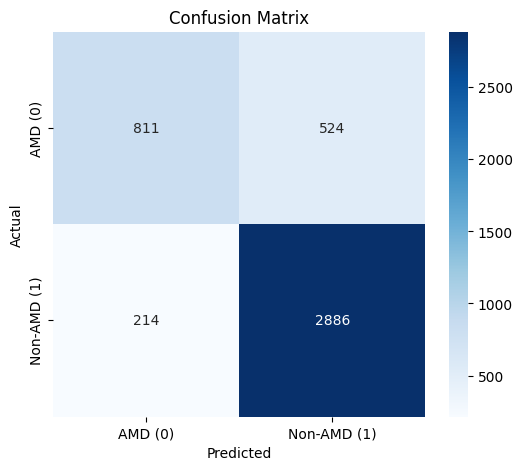

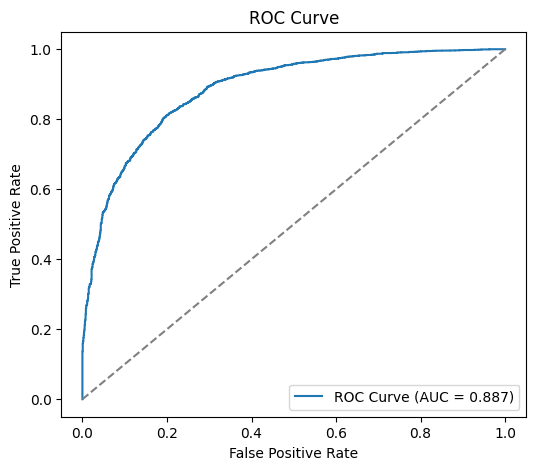

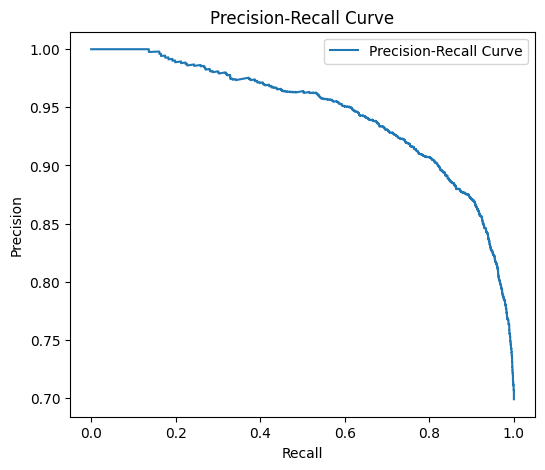

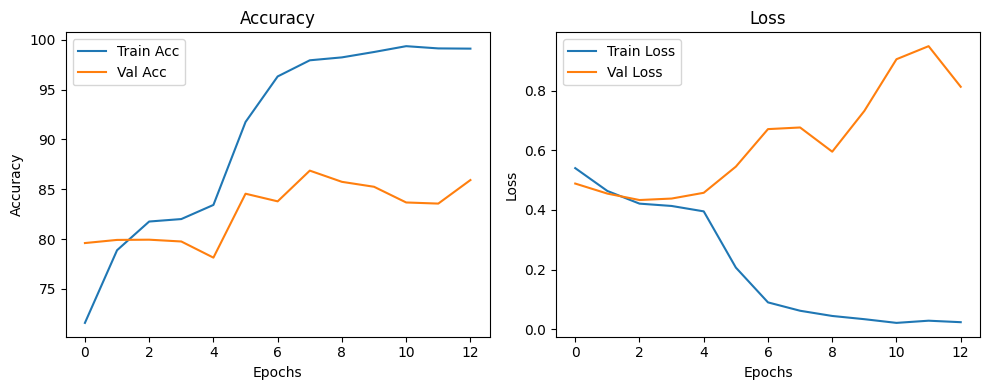

In [5]:
# === Imports ===

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# === Paths ===
train_dir = r"C:\Users\HP\Desktop\adam\adamtrain"
val_dir   = r"C:\Users\HP\Desktop\adam\adamval"
test_dir  = r"C:\Users\HP\Desktop\adam\adamtest"

# === Transforms (augment only train) ===
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Datasets ===
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data   = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data  = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# === Dataloaders ===
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

# === Model (ResNet50) ===
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # freeze all layers initially

# Replace final layer for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# === Loss, Optimizer, Scheduler ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

# === Training Function ===

def train_model(model, train_loader, val_loader, test_loader, epochs=30, patience=10):
    best_val_loss = float("inf")
    best_model_path = "best_resnet50.pth"
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    patience_counter = 0

    for epoch in range(epochs):
        # Gradual unfreezing after 5 epochs
        if epoch == 5:
            for param in model.layer4.parameters():
                param.requires_grad = True
            optimizer.add_param_group({'params': model.layer4.parameters(), 'lr': 5e-5})
            print("\n--> Unfroze layer4 for fine-tuning.")

        # === Training ===
        model.train()
        train_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss /= len(train_loader)

        # === Validation ===
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total
        val_loss /= len(val_loader)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2f}%")

        # === Early Stopping & Save Best Model ===
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("\nEarly stopping triggered.")
                break

    # === Load Best Model and Evaluate on Test Set ===
    print("\nLoading best model and evaluating on test data...")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # prob for class 1
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # === Classification Report ===
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=["AMD (0)", "Non-AMD (1)"]))

    # === Confusion Matrix ===
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["AMD (0)", "Non-AMD (1)"],
                yticklabels=["AMD (0)", "Non-AMD (1)"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # === ROC Curve ===
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # === Precision-Recall Curve ===
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label="Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # === Plot Accuracy and Loss ===
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")
    plt.tight_layout()
    plt.show()

    return history

# === Run Training with Early Stopping ===
history = train_model(model, train_loader, val_loader, test_loader, epochs=30, patience=10)

Using: cpu

Loaded saved model — continuing fine-tuning (all layers)...



C:\Ananconda\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/25 | Train Loss: 0.464, Train Acc: 86.46% | Val Loss: 0.679, Val Acc: 76.47%
Epoch 2/25 | Train Loss: 0.350, Train Acc: 93.23% | Val Loss: 0.724, Val Acc: 78.29%
Epoch 3/25 | Train Loss: 0.312, Train Acc: 96.00% | Val Loss: 0.656, Val Acc: 83.42%
Epoch 4/25 | Train Loss: 0.289, Train Acc: 98.11% | Val Loss: 0.655, Val Acc: 83.37%
EarlyStopping counter: 1/6
Epoch 5/25 | Train Loss: 0.283, Train Acc: 98.47% | Val Loss: 0.669, Val Acc: 82.83%
EarlyStopping counter: 2/6
Epoch 6/25 | Train Loss: 0.278, Train Acc: 98.65% | Val Loss: 0.653, Val Acc: 84.09%
Epoch 7/25 | Train Loss: 0.270, Train Acc: 99.15% | Val Loss: 0.645, Val Acc: 82.81%
EarlyStopping counter: 1/6
Epoch 8/25 | Train Loss: 0.266, Train Acc: 99.28% | Val Loss: 0.636, Val Acc: 83.58%
EarlyStopping counter: 2/6
Epoch 9/25 | Train Loss: 0.266, Train Acc: 99.35% | Val Loss: 0.620, Val Acc: 84.66%
Epoch 10/25 | Train Loss: 0.264, Train Acc: 99.33% | Val Loss: 0.627, Val Acc: 84.39%
EarlyStopping counter: 1/6
Epoch 11/25 | 

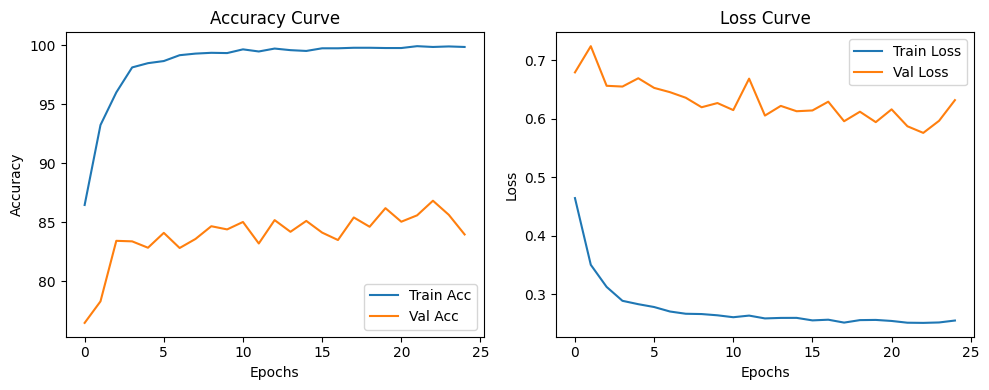


Loading best fine-tuned model and evaluating on test set...


Classification Report:
              precision    recall  f1-score   support

     AMD (0)       0.74      0.71      0.72      1335
 Non-AMD (1)       0.88      0.89      0.88      3100

    accuracy                           0.84      4435
   macro avg       0.81      0.80      0.80      4435
weighted avg       0.84      0.84      0.84      4435



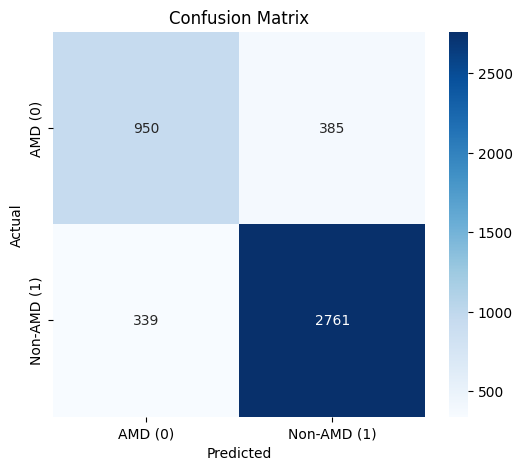

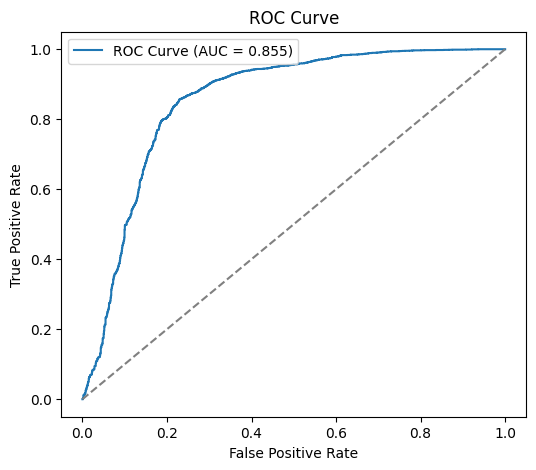

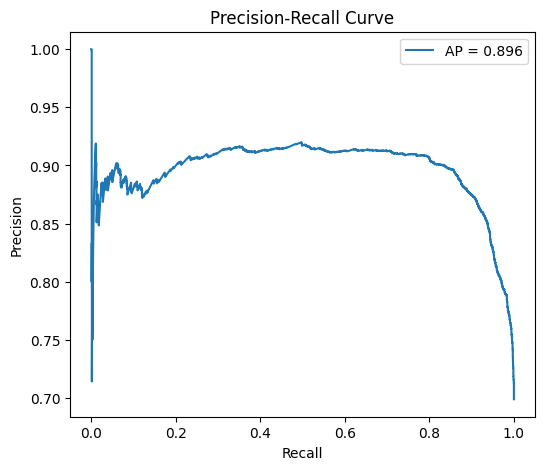

In [3]:
# Fine-tuning 

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# === Paths ===
train_dir = r"C:\Users\HP\Desktop\adam\adamtrain"
val_dir   = r"C:\Users\HP\Desktop\adam\adamval"
test_dir  = r"C:\Users\HP\Desktop\adam\adamtest"

# === Transforms ===
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Datasets & Loaders ===
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data   = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data  = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

# === Reload model ===
model = models.resnet50(pretrained=True)

# --- Add dropout before final FC ---
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 2)
)

state_dict = torch.load("best_resnet50.pth", map_location=device)

# Fix mismatch if old model had single Linear layer
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("fc.") and not k.startswith("fc.1."):
        new_state_dict[k.replace("fc.", "fc.1.")] = v
    else:
        new_state_dict[k] = v

model.load_state_dict(new_state_dict, strict=False)
model = model.to(device)

print("\nLoaded saved model — continuing fine-tuning (all layers)...\n")

# === Unfreeze all layers ===
for param in model.parameters():
    param.requires_grad = True

# === Weighted loss (for AMD imbalance) ===
# Compute class weights inversely proportional to frequency
labels = [label for _, label in train_data.samples]
class_sample_count = np.bincount(labels)
class_weights = 1. / torch.tensor(class_sample_count, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * 2.0
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)

# === Optimizer and Scheduler ===
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

# === Early Stopping ===
class EarlyStopping:
    def __init__(self, patience=6, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta

    def __call__(self, val_acc, model):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), "best_resnet50_finetuned_v2.pth")

# === Training Function ===
def train_model(model, train_loader, val_loader, epochs=25):
    early_stopping = EarlyStopping(patience=6)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss /= len(train_loader)

        # === Validation ===
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2f}%")
        early_stopping(val_acc, model)
        if early_stopping.early_stop:
            print("\nEarly stopping triggered.\n")
            break

    model.load_state_dict(torch.load("best_resnet50_finetuned_v2.pth"))
    return history

# === Train ===
history = train_model(model, train_loader, val_loader, epochs=25)

# === Plot Accuracy & Loss Curves ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curve")
plt.tight_layout()
plt.show()

# === Test Evaluation ===
print("\nLoading best fine-tuned model and evaluating on test set...\n")
model.load_state_dict(torch.load("best_resnet50_finetuned_v2.pth"))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# === Classification Report ===
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["AMD (0)", "Non-AMD (1)"]))

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AMD (0)", "Non-AMD (1)"],
            yticklabels=["AMD (0)", "Non-AMD (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# === ROC Curve ===
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.show()

# === Precision-Recall Curve ===
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve"); plt.legend()
plt.show()